In [1]:
import sys
from pathlib import Path

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


Chargé : 2667 frames à 33.3 fps
FPS: 33.341
Frame shape: (562, 706)


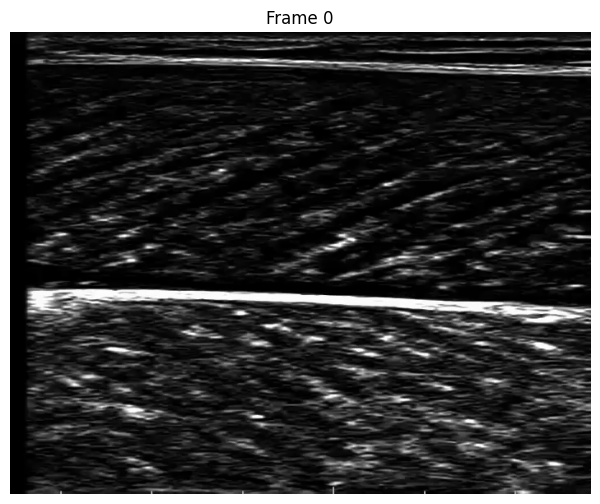

In [2]:
import matplotlib.pyplot as plt

from ultrasound_tracker.legacy.preprocessing import load_video
from ultrasound_tracker.roi import (
    select_all_rois_cv2,
    draw_rois,
    extract_roi,
    save_rois,
    load_rois,
)

VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"

frames, fps = load_video(str(VIDEO_PATH))
frame0 = frames[0]

print("FPS:", fps)
print("Frame shape:", frame0.shape)

plt.figure(figsize=(10, 6))
plt.imshow(frame0, cmap="gray")
plt.title("Frame 0")
plt.axis("off")
plt.show()

In [3]:
rois = select_all_rois_cv2(frame0, include_fascicle_roi=True)

print(rois)

Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
{'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}


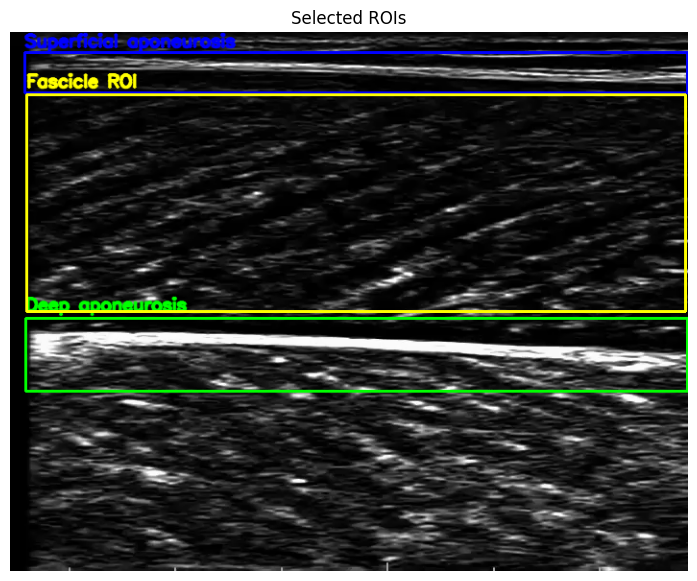

In [4]:
vis = draw_rois(frame0, rois)

plt.figure(figsize=(12, 7))
plt.imshow(vis[..., ::-1])  # BGR to RGB for matplotlib
plt.title("Selected ROIs")
plt.axis("off")
plt.show()

In [6]:
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"

save_rois(rois, ROI_PATH)

print("ROIs sauvegardées dans :", ROI_PATH)

ROIs sauvegardées dans : /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json


{'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}


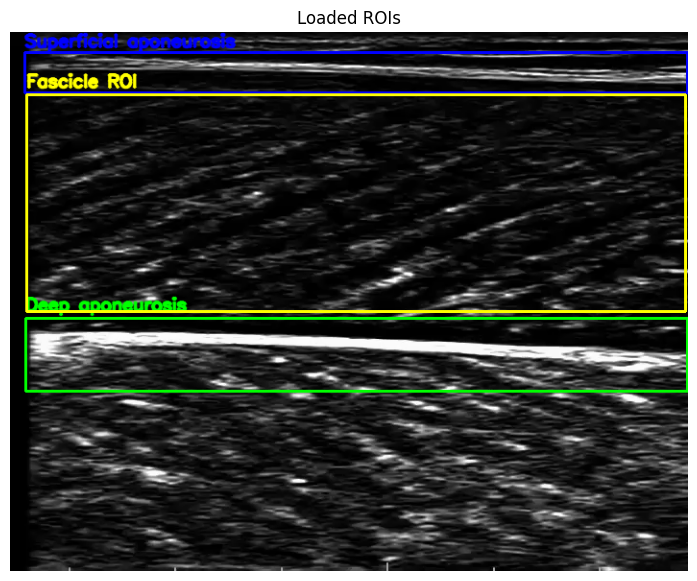

In [7]:
rois_loaded = load_rois(ROI_PATH)

print(rois_loaded)

vis = draw_rois(frame0, rois_loaded)

plt.figure(figsize=(12, 7))
plt.imshow(vis[..., ::-1])
plt.title("Loaded ROIs")
plt.axis("off")
plt.show()

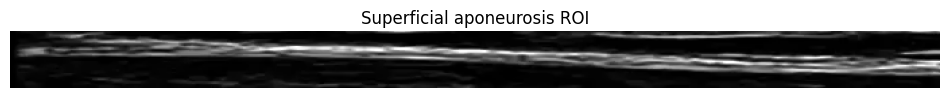

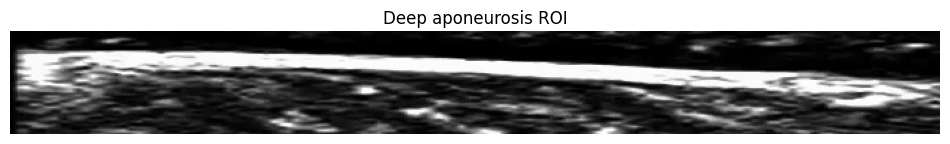

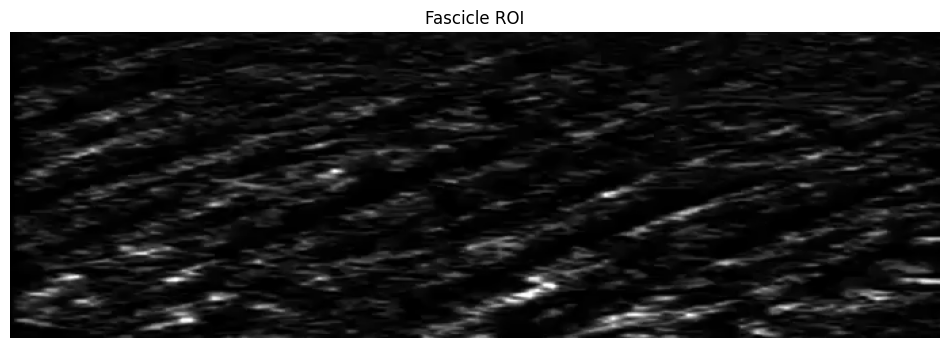

In [8]:
sup_roi_img = extract_roi(frame0, rois["superficial"])
deep_roi_img = extract_roi(frame0, rois["deep"])
fas_roi_img = extract_roi(frame0, rois["fascicle"])

plt.figure(figsize=(12, 4))
plt.imshow(sup_roi_img, cmap="gray")
plt.title("Superficial aponeurosis ROI")
plt.axis("off")
plt.show()

plt.figure(figsize=(12, 4))
plt.imshow(deep_roi_img, cmap="gray")
plt.title("Deep aponeurosis ROI")
plt.axis("off")
plt.show()

plt.figure(figsize=(12, 4))
plt.imshow(fas_roi_img, cmap="gray")
plt.title("Fascicle ROI")
plt.axis("off")
plt.show()